In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("../data/processed/Chocolate_Sales_Curated.csv")

In [15]:
# Sort df by date
df_sorted = df.sort_values("date").reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"], errors='coerce')

y = df["amount"]
X_encoded = pd.read_csv("../data/processed/X_encoded.csv")

# Split: 80% train 20% test
split_idx = int(len(df_sorted) * 0.8)
X_train = X_encoded[:split_idx]
X_test = X_encoded[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (2625, 56), Test shape: (657, 56)


In [3]:
# Baseline: predict mereu mean din train
y_pred_mean = [y_train.mean()] * len(y_test)
mae_mean = mean_absolute_error(y_test, y_pred_mean)
print(f"Baseline Mean MAE: {mae_mean:.2f}")

# Baseline: predict mereu median din train
y_pred_median = [y_train.median()] * len(y_test)
mae_median = mean_absolute_error(y_test, y_pred_median)
print(f"Baseline Median MAE: {mae_median:.2f}")

Baseline Mean MAE: 3749.19
Baseline Median MAE: 3759.94


In [4]:
# TimeSeriesSplit pentru date temporale
tscv = TimeSeriesSplit(n_splits=5)

# Exemplu pentru Ridge
ridge = Ridge(alpha=1)
cv_scores = cross_val_score(ridge, X_train, y_train, cv=tscv, scoring="neg_mean_absolute_error")
print(f"Ridge CV MAE (negativ): {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

Ridge CV MAE (negativ): -3481.35 (+/- 41.43)


In [5]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest Test MAE: {mae_rf:.2f}")

Random Forest Test MAE: 1757.55


In [6]:
pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

boxes_shipped                       0.197448
month                               0.084090
day_of_week                         0.040058
product_Organic Choco Syrup         0.023520
country_USA                         0.022204
country_UK                          0.020847
country_Australia                   0.019964
country_India                       0.019579
sales_person_Ches Bonnell           0.019343
country_New Zealand                 0.018882
product_Smooth Sliky Salty          0.018707
country_Canada                      0.017532
product_99% Dark & Pure             0.016691
sales_person_Kelci Walkden          0.016009
sales_person_Van Tuxwell            0.015590
sales_person_Marney O'Breen         0.015160
sales_person_Brien Boise            0.014922
product_Mint Chip Choco             0.014743
sales_person_Jan Morforth           0.014414
product_50% Dark Bites              0.014406
sales_person_Beverie Moffet         0.014096
product_Peanut Butter Cubes         0.014046
sales_pers

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE: medie erori absolute
mae = mean_absolute_error(y_test, y_pred_rf)
print(f"MAE: {mae:.2f}")

# RMSE: rădăcina pătrată din MSE (penalizează erori mari mai tare)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE: {rmse:.2f}")

# R²: câtă variație explică modelul (1.0 = perfect, 0 = ca baseline mean)
r2 = r2_score(y_test, y_pred_rf)
print(f"R²: {r2:.3f}")

MAE: 1757.55
RMSE: 2318.42
R²: 0.754


In [8]:
# Baseline: mean din train
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline - rf_mae: {baseline_mae - mae:.2f}")

Baseline MAE: 3749.19
Baseline - rf_mae: 1991.64


MAE per țară (top cele mai slabe):
country
India          2141.909256
UK             1828.846424
USA            1772.062652
Canada         1656.334806
Australia      1580.674689
New Zealand    1574.185150
Name: error, dtype: float64

MAE per produs (top cele mai slabe):
product
Manuka Honey Choco      2552.884593
Milk Bars               2241.337645
Peanut Butter Cubes     2131.124842
Smooth Sliky Salty      2002.558142
85% Dark Bars           1977.286859
99% Dark & Pure         1952.476967
Almond Choco            1855.466450
Baker's Choco Chips     1852.772288
Choco Coated Almonds    1804.028926
50% Dark Bites          1764.508658
Name: error, dtype: float64


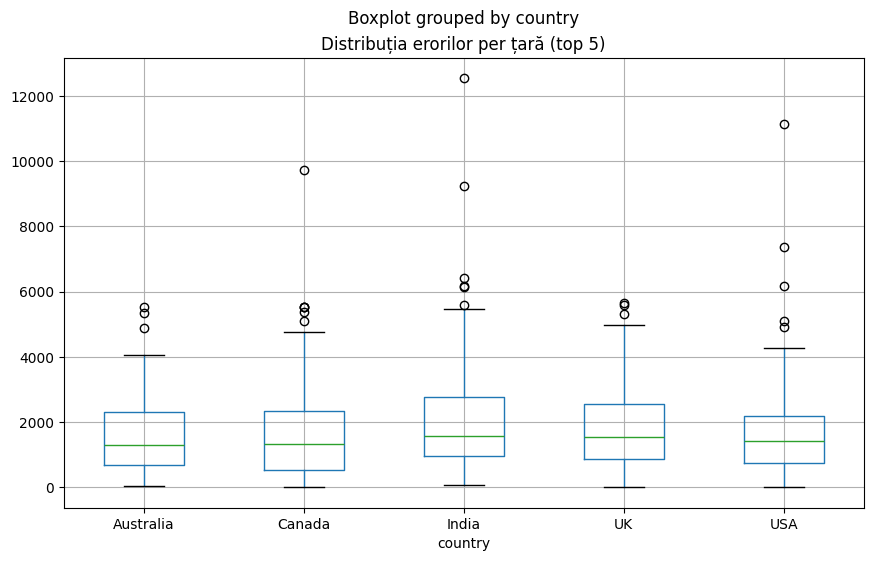

In [9]:
df_test = df.iloc[split_idx:].copy()  # din split-ul anterior
df_test["y_true"] = y_test
df_test["y_pred"] = y_pred_rf
df_test["error"] = abs(df_test["y_true"] - df_test["y_pred"])  # eroare absolută

# MAE per country
mae_country = df_test.groupby("country")["error"].mean().sort_values(ascending=False)
print("MAE per țară (top cele mai slabe):")
print(mae_country.head(10))

# MAE per product
mae_product = df_test.groupby("product")["error"].mean().sort_values(ascending=False)
print("\nMAE per produs (top cele mai slabe):")
print(mae_product.head(10))

# Vizualizează
top_countries = mae_country.head(5).index
df_subset = df_test[df_test["country"].isin(top_countries)]
df_subset.boxplot(column="error", by="country", figsize=(10,6))
plt.title("Distribuția erorilor per țară (top 5)")
plt.show()

Feature importance (RF built-in):
boxes_shipped                  0.197448
month                          0.084090
day_of_week                    0.040058
product_Organic Choco Syrup    0.023520
country_USA                    0.022204
country_UK                     0.020847
country_Australia              0.019964
country_India                  0.019579
sales_person_Ches Bonnell      0.019343
country_New Zealand            0.018882
dtype: float64


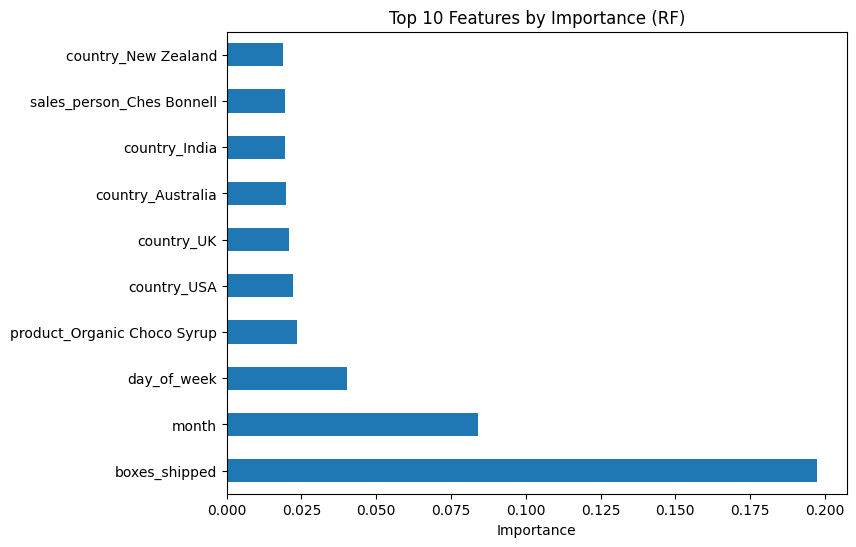

In [10]:
# După fit-ul RF
feature_importance_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature importance (RF built-in):")
print(feature_importance_rf.head(10))

# Plot top 10
feature_importance_rf.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Features by Importance (RF)")
plt.xlabel("Importance")
plt.show()

Permutation importance (mean decrease in score):
boxes_shipped                  1418.758304
month                          1007.129269
country_India                   220.729677
country_USA                     173.210839
country_New Zealand             171.393645
country_UK                      162.414617
country_Australia               146.145682
product_Peanut Butter Cubes     133.844289
country_Canada                  128.735658
product_Drinking Coco           117.826593
dtype: float64


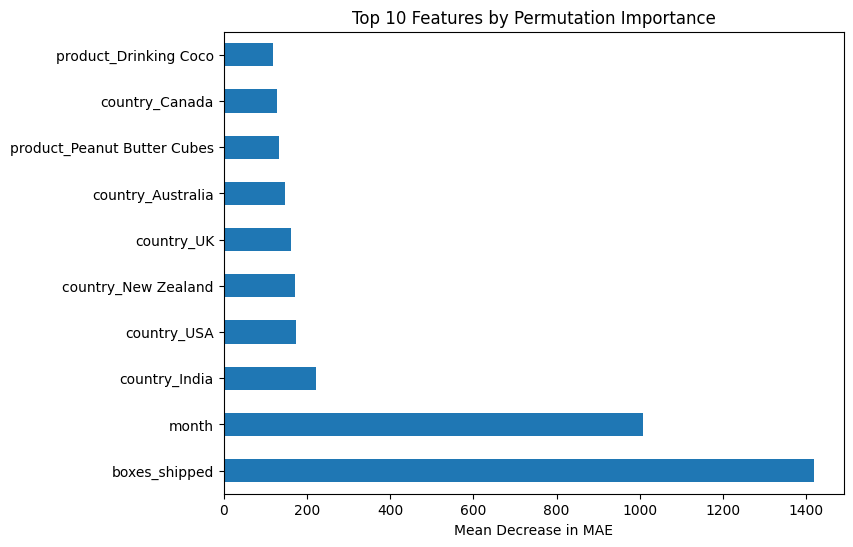

In [11]:
from sklearn.inspection import permutation_importance

# Calculează pe test set
perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_absolute_error")
perm_importance_df = pd.Series(perm_importance.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Permutation importance (mean decrease in score):")
print(perm_importance_df.head(10))

# Plot
perm_importance_df.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Top 10 Features by Permutation Importance")
plt.xlabel("Mean Decrease in MAE")
plt.show()

Monthly Sales MAE: 67334.58


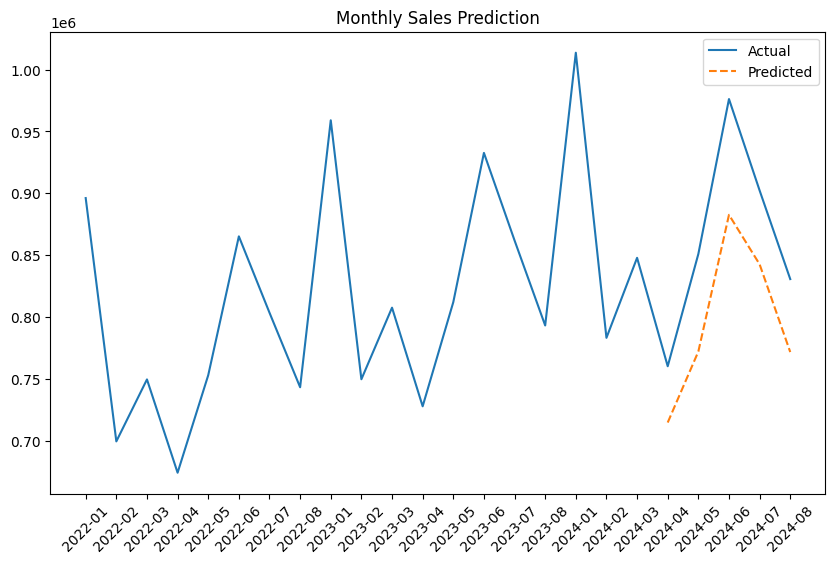

In [23]:
# Agregă monthly totals
df_sorted = df.sort_values("date").reset_index(drop=True)
# Adaugă conversia la datetime (lipsă în codul tău original)
df_sorted["date"] = pd.to_datetime(df_sorted["date"], errors='coerce')

monthly_sales = df_sorted.groupby(df_sorted["date"].dt.to_period("M"))["amount"].sum().reset_index()
monthly_sales.columns = ["month_period", "total_amount"]
monthly_sales["month_num"] = monthly_sales["month_period"].dt.month

# Features simple pentru regresie
X_monthly = monthly_sales[["month_num"]]
y_monthly = monthly_sales["total_amount"]

# Split
split_idx_m = int(len(monthly_sales) * 0.8)
X_train_m = X_monthly[:split_idx_m]
y_train_m = y_monthly[:split_idx_m]
X_test_m = X_monthly[split_idx_m:]
y_test_m = y_monthly[split_idx_m:]

# Model RF pe monthly
rf_monthly = RandomForestRegressor(n_estimators=100, random_state=42)
rf_monthly.fit(X_train_m, y_train_m)
y_pred_m = rf_monthly.predict(X_test_m)
mae_monthly = mean_absolute_error(y_test_m, y_pred_m)
print(f"Monthly Sales MAE: {mae_monthly:.2f}")

# Plot
plt.figure(figsize=(10,6))
plt.plot(monthly_sales["month_period"].astype(str), monthly_sales["total_amount"], label="Actual")
plt.plot(monthly_sales["month_period"].astype(str)[split_idx_m:], y_pred_m, label="Predicted", linestyle="--")
plt.title("Monthly Sales Prediction")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("../reports/figures/monthly_sales.png")

In [21]:
# Asigură că ai import os
import os
os.makedirs("../reports/figures", exist_ok=True)

report_content = f"""
# Chocolate Sales Model Report

## Dataset Overview
- Total rows: {len(df)}
- Train/Test split: {split_idx}/{len(df) - split_idx}

## Metrics (Random Forest)
- MAE: {mae:.2f}
- RMSE: {rmse:.2f}
- R²: {r2:.3f}
- Baseline MAE: {baseline_mae:.2f}
- Improvement over baseline: {baseline_mae - mae:.2f}

## Top Errors
- MAE per country (top 3): {mae_country.head(3).to_dict()}
- MAE per product (top 3): {mae_product.head(3).to_dict()}

## Top Features (RF Built-in)
{feature_importance_rf.head(5).to_string()}

## Top Features (Permutation)
{perm_importance_df.head(5).to_string()}

## Stretch Goals
- Weekend feature added: Yes
- Monthly sales MAE: {mae_monthly:.2f} (if run)

## Conclusions
Modelul Random Forest are MAE {mae:.2f}, explicând {r2:.1%} din variație.
Top feature: {feature_importance_rf.index[0]}.
Erorile sunt mari în țările cu puține date – recomandăm mai multe features sau date.

![Feature Importance](figures/feature_importance_rf.png)
![Errors by Country](figures/errors_by_country.png)
"""

with open("../reports/model_report.md", "w", encoding="utf-8") as f:
    f.write(report_content)